# Phase 2: Layer 2 — Decision-Making Bias Analysis (RQ2)

**Project:** A Perception-Aware Framework for Evaluating Counterfactual Passing Options in Professional Football
**Author:** Raeesa Lorgat (2686242)

**Purpose of this notebook:** Layer 1 (see `setup_euro2024.ipynb`) established which teammates a player could realistically see at the moment of a pass, and answered RQ1 which was whether that visibility filter changes what counts as the "optimal" pass. This notebook builds Layer 2, which asks a different question: **among the teammates a player could see, how often did they bypass a genuinely better option?**

Answering that fairly requires narrowing "visible teammates" down to teammates who were also **legitimate** alternatives meaning not offside, and not unrealistically difficult to reach. This notebook adds those two filters before computing the forward-progressive bias rate specified in the proposal (Section 4.5.2):

1. **Offside detection** : using 360 freeze-frame defender positions, determine whether each candidate teammate was onside at the moment of the pass.
2. **xP (expected pass completion probability)** : weight candidates by how realistically executable the pass was, based on distance, angle, and defender proximity.
3. **Forward-progressive classification** : using Karun Singh's public xT grid, identify which remaining candidates represent a genuine forward-progressive improvement over the pass actually made.

**What this notebook reuses rather than recomputes:** the vision-cone classification logic (`src/vision_cone.py`), the trained VAEP models, and the RQ1 counterfactual results (`cf_valid`, `cf_valid_all3`) and are all loaded from disk, not rebuilt from scratch.

**Environment:** same venv/kernel as `01_setup_euro2024.ipynb` (Python 3.11.2) so no new packages beyond `socceraction`'s `xthreat` module, already installed.

In [1]:
import os
os.environ["SBOPENDATAPATH"] = r"C:\Users\raees\Documents\Honours\My Research\Code\open-data\data"

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mplsoccer import Pitch
import sys
sys.path.append('..')

from src.vision_cone import angle_to_teammate

import socceraction.xthreat as xthreat
xT_model = xthreat.load_model("https://karun.in/blog/data/open_xt_12x8_v1.json")

# reload everything already computed in notebook 1 — no need to recompute
cf_valid = pd.read_pickle('../data/results/rq1_counterfactual_comparison.pkl')
cf_valid_all3 = pd.read_pickle('../data/results/rq1_counterfactual_comparison_all3.pkl')

Offside detection using the 360 freeze frame

A candidate teammate is offside if they're closer to the opponent's goal line than both the ball and the second-deepest defender at that moment, the goalkeeper included in that ordering, not automatically excluded (in practice they're usually deepest, but not always).

To determine which end each team is defending, since raw StatsBomb coordinates don't self-adjust for attacking direction, this uses the opposing goalkeeper's position, already present in the same 360 freeze frame via the `keeper` flag. Wherever the opponent keeper stands tells us which end the passer's team is attacking toward, with no separate lookup needed.

In [4]:
from src.vision_cone import add_orientation_vectors, build_pass_visibility_table
from statsbombpy import sb
import pandas as pd
import time
from pathlib import Path

# route around raw.githubusercontent.com's outage via the jsDelivr mirror
import statsbombpy.public as sbpublic
sbpublic.OPEN_DATA_PATHS = {
    k: v.replace(
        "https://raw.githubusercontent.com/statsbomb/open-data/master",
        "https://cdn.jsdelivr.net/gh/statsbomb/open-data@master"
    )
    for k, v in sbpublic.OPEN_DATA_PATHS.items()
}

CACHE_DIR = Path("../data/statsbomb_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def cached_events(match_id, retries=5, backoff=5):
    cache_file = CACHE_DIR / f"events_{match_id}.pkl"
    if cache_file.exists():
        return pd.read_pickle(cache_file)
    for attempt in range(retries):
        try:
            events = sb.events(match_id=match_id)
            events.to_pickle(cache_file)
            return events
        except Exception as e:
            if attempt == retries - 1:
                raise
            wait = backoff * (attempt + 1)
            print(f"events fetch failed ({e}), retrying in {wait}s...")
            time.sleep(wait)

def cached_frames(match_id, retries=5, backoff=5):
    cache_file = CACHE_DIR / f"frames_{match_id}.pkl"
    if cache_file.exists():
        return pd.read_pickle(cache_file)
    for attempt in range(retries):
        try:
            frames = sb.frames(match_id=match_id, fmt='dataframe')
            frames.to_pickle(cache_file)
            return frames
        except Exception as e:
            if attempt == retries - 1:
                raise
            wait = backoff * (attempt + 1)
            print(f"frames fetch failed ({e}), retrying in {wait}s...")
            time.sleep(wait)

sample_match_id = "3943043"  # reuse the Euro 2024 final
m_events = cached_events(sample_match_id)
m_events_oriented = add_orientation_vectors(m_events)
m_frames = cached_frames(sample_match_id)

sample_pass_events = m_events_oriented[
    (m_events_oriented['type'] == 'Pass') &
    (m_events_oriented['orientation_vector'].notna())
]
sample = sample_pass_events.iloc[50]
event_id = sample['id']

frame = m_frames[m_frames['id'] == event_id]
opponent_keeper = frame[(frame['teammate'] == False) & (frame['keeper'] == True)]

print(f"Opponent keeper found in this frame: {not opponent_keeper.empty}")
if not opponent_keeper.empty:
    print(f"Opponent keeper location: {opponent_keeper.iloc[0]['location']}")
print(f"Passer location: {sample['location']}")

Opponent keeper found in this frame: True
Opponent keeper location: [115.6168082840095, 43.25187666650353]
Passer location: [92.4, 23.2]


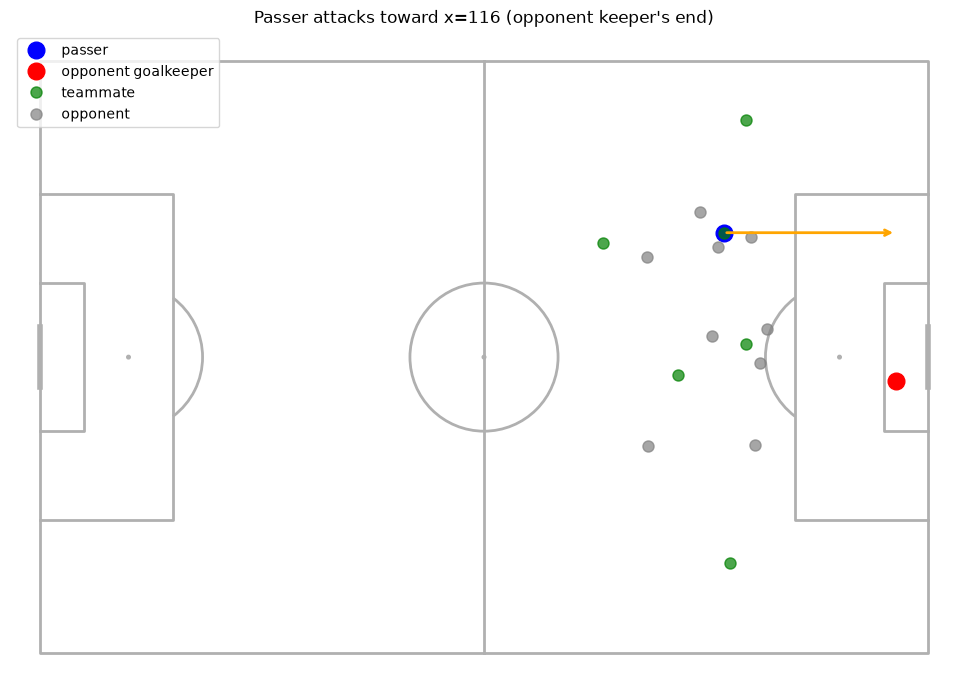

In [5]:
pitch = Pitch(pitch_type='statsbomb')
fig, ax = pitch.draw(figsize=(10, 7))

passer_loc = sample['location']
keeper_loc = opponent_keeper.iloc[0]['location']

# passer
ax.plot(passer_loc[0], passer_loc[1], 'o', color='blue', markersize=12, label='passer')

# opponent goalkeeper
ax.plot(keeper_loc[0], keeper_loc[1], 'o', color='red', markersize=12, label='opponent goalkeeper')

# all other players in the frame, for context
others = frame[
    (frame['id'] == event_id) &
    ~((frame['teammate'] == False) & (frame['keeper'] == True))
]

teammates_plotted = False
opponents_plotted = False

for _, row in others.iterrows():
    loc = row['location']
    if row['teammate']:
        label = 'teammate' if not teammates_plotted else None
        ax.plot(loc[0], loc[1], 'o', color='green', markersize=8, alpha=0.7, label=label)
        teammates_plotted = True
    else:
        label = 'opponent' if not opponents_plotted else None
        ax.plot(loc[0], loc[1], 'o', color='grey', markersize=8, alpha=0.7, label=label)
        opponents_plotted = True

# arrow showing implied attacking direction: passer toward keeper's end
attacking_toward_x = keeper_loc[0]
ax.annotate('', xy=(min(attacking_toward_x, 118), passer_loc[1]), xytext=(passer_loc[0], passer_loc[1]),
            arrowprops=dict(arrowstyle='->', color='orange', lw=2))

ax.legend(loc='upper left')
ax.set_title(f"Passer attacks toward x={attacking_toward_x:.0f} (opponent keeper's end)")
plt.show()

Compute the offside line for this pass

The offside line is defined by the second-deepest defender (opponent), sorted by proximity to their own goal, the goalkeeper included in that ordering, not excluded by default. "Deepest" means closest to the goal line the defending team is protecting, which we now know from the opponent keeper's position: if the keeper sits near x=120, the defending team's goal is at x=120, so "deepest" means highest x.

A candidate teammate is offside if their x-position is beyond both the ball's position and the second-deepest defender's x-position, on the attacking side.

In [6]:
def compute_offside_line(frame_at_event, attacking_toward_x):
    """
    Given all players in a 360 frame and the x-coordinate the attacking team
    is attacking toward, return the offside line x-coordinate: the position
    of the second-deepest defender (goalkeeper included in the sort).
    """
    defenders = frame_at_event[frame_at_event['teammate'] == False].copy()
    if len(defenders) < 2:
        return None  # not enough defenders visible to determine a line

    defenders['x'] = defenders['location'].apply(lambda loc: loc[0])

    # "deepest" = closest to the goal they're defending
    if attacking_toward_x > 60:
        # defending team's goal is at high x -> deepest defender has HIGHEST x
        sorted_defenders = defenders.sort_values('x', ascending=False)
    else:
        # defending team's goal is at low x -> deepest defender has LOWEST x
        sorted_defenders = defenders.sort_values('x', ascending=True)

    second_deepest_x = sorted_defenders.iloc[1]['x']
    return second_deepest_x


def is_offside(candidate_x, ball_x, offside_line_x, attacking_toward_x):
    """
    A candidate is offside if they are beyond BOTH the ball and the
    second-deepest defender, on the attacking side.
    """
    if offside_line_x is None:
        return False  # can't determine, default to not-offside (conservative)

    if attacking_toward_x > 60:
        return candidate_x > ball_x and candidate_x > offside_line_x
    else:
        return candidate_x < ball_x and candidate_x < offside_line_x


# test on this sample pass
offside_line_x = compute_offside_line(frame[frame['id'] == event_id], attacking_toward_x)
print(f"Offside line x-coordinate: {offside_line_x:.2f}")
print(f"Ball (pass start) x-coordinate: {passer_loc[0]:.2f}")

teammates_in_frame = frame[(frame['id'] == event_id) & (frame['teammate'] == True)]
for _, row in teammates_in_frame.iterrows():
    tx = row['location'][0]
    offside = is_offside(tx, passer_loc[0], offside_line_x, attacking_toward_x)
    print(f"  Teammate at x={tx:.2f}: {'OFFSIDE' if offside else 'onside'}")

Offside line x-coordinate: 98.23
Ball (pass start) x-coordinate: 92.40
  Teammate at x=76.00: onside
  Teammate at x=86.22: onside
  Teammate at x=92.40: onside
  Teammate at x=93.26: onside
  Teammate at x=95.40: onside
  Teammate at x=95.42: onside


In [7]:
# scan a handful of passes in this match looking for a genuine offside case
for idx in range(0, 200):
    test_sample = sample_pass_events.iloc[idx]
    test_event_id = test_sample['id']
    test_frame_data = m_frames[m_frames['id'] == test_event_id]

    test_keeper = test_frame_data[(test_frame_data['teammate'] == False) & (test_frame_data['keeper'] == True)]
    if test_keeper.empty:
        continue

    test_attacking_toward_x = test_keeper.iloc[0]['location'][0]
    test_offside_line = compute_offside_line(test_frame_data, test_attacking_toward_x)
    if test_offside_line is None:
        continue

    test_ball_x = test_sample['location'][0]
    test_teammates = test_frame_data[test_frame_data['teammate'] == True]

    for _, row in test_teammates.iterrows():
        tx = row['location'][0]
        if is_offside(tx, test_ball_x, test_offside_line, test_attacking_toward_x):
            print(f"Found offside candidate at pass index {idx}, event_id {test_event_id}")
            print(f"  Candidate x={tx:.2f}, offside line={test_offside_line:.2f}, ball x={test_ball_x:.2f}")
            break

Found offside candidate at pass index 78, event_id dd7c66d5-69c1-48dc-b931-204ba90f0a70
  Candidate x=110.25, offside line=109.80, ball x=106.50
Found offside candidate at pass index 158, event_id a8241a9b-b73e-4f83-8506-8895c29647c1
  Candidate x=112.51, offside line=109.82, ball x=100.20
Found offside candidate at pass index 187, event_id e02750b9-17cb-4509-bfed-0bea551126bf
  Candidate x=104.35, offside line=103.35, ball x=81.00
Found offside candidate at pass index 189, event_id 81c1c2ec-9c0b-4cae-90f8-09c5e0c358d2
  Candidate x=105.33, offside line=104.16, ball x=90.10
Found offside candidate at pass index 190, event_id f3f38929-16fa-412d-950b-096b105dd69f
  Candidate x=99.92, offside line=99.60, ball x=80.40


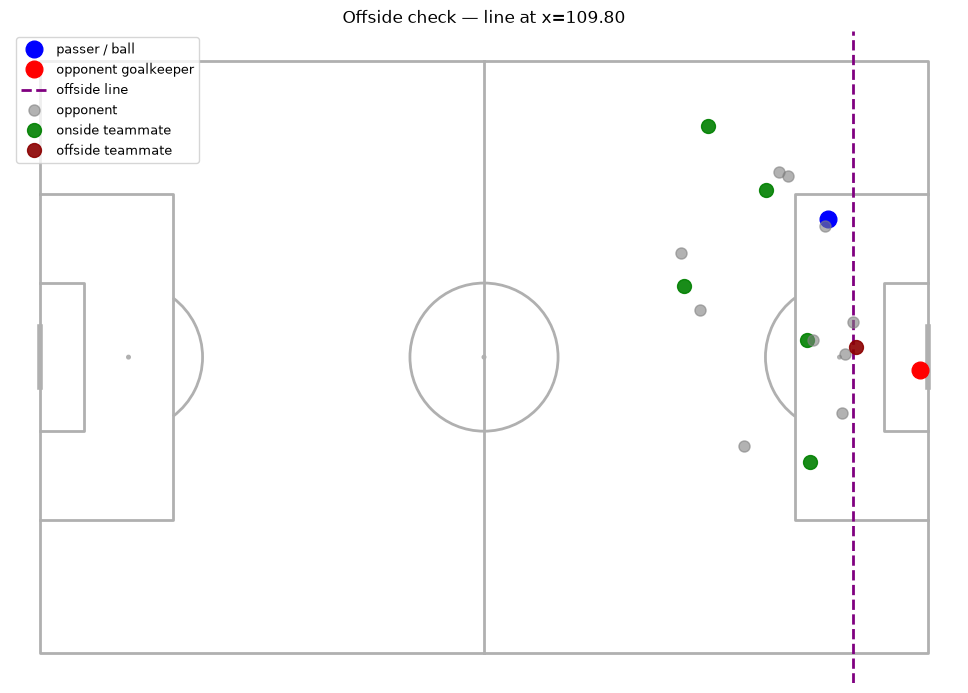

In [8]:
test_event_id = "dd7c66d5-69c1-48dc-b931-204ba90f0a70"
test_sample = sample_pass_events[sample_pass_events['id'] == test_event_id].iloc[0]
test_frame_data = m_frames[m_frames['id'] == test_event_id]

test_keeper = test_frame_data[(test_frame_data['teammate'] == False) & (test_frame_data['keeper'] == True)]
test_attacking_toward_x = test_keeper.iloc[0]['location'][0]
test_offside_line = compute_offside_line(test_frame_data, test_attacking_toward_x)
test_ball_loc = test_sample['location']

pitch = Pitch(pitch_type='statsbomb')
fig, ax = pitch.draw(figsize=(10, 7))

# ball / passer
ax.plot(test_ball_loc[0], test_ball_loc[1], 'o', color='blue', markersize=12, label='passer / ball')

# opponent keeper
ax.plot(test_keeper.iloc[0]['location'][0], test_keeper.iloc[0]['location'][1],
        'o', color='red', markersize=12, label='opponent goalkeeper')

# offside line, drawn vertically across the pitch
ax.axvline(test_offside_line, color='purple', linestyle='--', linewidth=2, label='offside line')

# all other players
teammates_plotted, opponents_plotted = False, False
for _, row in test_frame_data.iterrows():
    if row.get('actor', False):
        continue
    loc = row['location']
    if row['teammate']:
        tx = loc[0]
        is_off = is_offside(tx, test_ball_loc[0], test_offside_line, test_attacking_toward_x)
        color = 'darkred' if is_off else 'green'
        label = ('offside teammate' if is_off else 'onside teammate')
        ax.plot(loc[0], loc[1], 'o', color=color, markersize=10, alpha=0.9,
                label=label if (is_off or not teammates_plotted) else None)
        teammates_plotted = True
    else:
        if row.get('keeper', False):
            continue
        label = 'opponent' if not opponents_plotted else None
        ax.plot(loc[0], loc[1], 'o', color='grey', markersize=8, alpha=0.6, label=label)
        opponents_plotted = True

ax.legend(loc='upper left', fontsize=9)
ax.set_title(f"Offside check — line at x={test_offside_line:.2f}")
plt.show()

In [9]:
from src.offside import classify_offside

# re-run your positive-case example using the packaged version
test_result = classify_offside(test_frame_data, test_ball_loc)
print(test_result[['location', 'attacking_toward_x', 'offside']])

                                      location  attacking_toward_x  offside
5157   [86.98170306169067, 30.330890071052735]           118.92478    False
5159    [90.29616167172878, 8.853739984723603]           118.92478    False
5161   [98.01765786485447, 17.398890401235548]           118.92478    False
5164   [103.57368170361602, 37.71423300958111]           118.92478    False
5165   [104.08121642159668, 54.15448454050586]           118.92478    False
5168               [106.5, 21.399999618530273]           118.92478    False
5172  [110.25204370788717, 38.674589868141815]           118.92478     True


Building xP (expected pass completion probability)

Per the proposal (Section 2.3.1), xP is modeled via logistic regression using pass distance, angle relative to the nearest defender, and player density in the target zone. Unlike xT, there's no public pretrained model for this, it's trained on my own data, same as VAEP.

**Training labels:** whether a real pass succeeded or failed (already in the data via `result_name`).
**Training features:** built from the passer's location, the candidate's location, and defender positions in the same 360 freeze frame.

In [10]:
def compute_xp_features(passer_loc, target_loc, frame_at_event):
    """
    Compute distance, angle-to-nearest-defender, and defender density
    features for a pass from passer_loc to target_loc, given the 360 frame.
    """
    dx = target_loc[0] - passer_loc[0]
    dy = target_loc[1] - passer_loc[1]
    pass_distance = np.sqrt(dx**2 + dy**2)

    defenders = frame_at_event[frame_at_event['teammate'] == False]
    if defenders.empty:
        nearest_defender_dist = 99.0
        defender_density = 0
    else:
        defender_dists = defenders['location'].apply(
            lambda loc: np.sqrt((loc[0] - target_loc[0])**2 + (loc[1] - target_loc[1])**2)
        )
        nearest_defender_dist = defender_dists.min()
        defender_density = (defender_dists < 5).sum()  # defenders within 5m of target

    return {
        'pass_distance': pass_distance,
        'nearest_defender_dist': nearest_defender_dist,
        'defender_density': defender_density
    }

# test on the same sample pass
test_features = compute_xp_features(test_ball_loc, test_ball_loc, test_frame_data)  # placeholder target
print(test_features)

{'pass_distance': 0.0, 'nearest_defender_dist': 1.0199769368455094, 'defender_density': 1}


Distance 0 makes sense since we used a placeholder

Build training data from real passes in this match

For every pass with usable 360 data, compute the same three features using the pass's *actual* end location, and label it with whether the pass succeeded or failed. This becomes the training set for the xP logistic regression.

In [11]:
xp_training_rows = []

for _, row in sample_pass_events.iterrows():
    event_id = row['id']
    frame_at_event = m_frames[m_frames['id'] == event_id]
    if frame_at_event.empty:
        continue

    pass_end = row.get('pass_end_location')
    if pass_end is None or not isinstance(pass_end, list):
        continue

    features = compute_xp_features(row['location'], pass_end, frame_at_event)
    features['success'] = 1 if pd.isna(row['pass_outcome']) else 0  # NaN = success in StatsBomb's convention
    xp_training_rows.append(features)

xp_train_df = pd.DataFrame(xp_training_rows)
print(f"{len(xp_train_df)} training examples")
print(xp_train_df['success'].value_counts())
xp_train_df.describe()

667 training examples
success
1    560
0    107
Name: count, dtype: int64


,pass_distance,nearest_defender_dist,defender_density,success
count,667.000000,667.000000,667.000000,667.00000
mean,21.186093,12.738643,0.227886,0.83958
std,14.347803,8.367807,0.614345,0.36727
min,1.264911,0.128715,0.000000,0.00000
25%,11.788640,6.641497,0.000000,1.00000
50%,17.978876,11.029287,0.000000,1.00000
75%,25.790595,17.354724,0.000000,1.00000
max,98.177900,54.264413,5.000000,1.00000


Fit the xP logistic regression

Same pattern as VAEP: single-match training data is too small to generalize (667 examples, one match), so this is a validation of the pipeline on one match before scaling to the full competition for the real model.

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

X_xp = xp_train_df[['pass_distance', 'nearest_defender_dist', 'defender_density']]
y_xp = xp_train_df['success']

X_xp_train, X_xp_test, y_xp_train, y_xp_test = train_test_split(X_xp, y_xp, test_size=0.2, random_state=42)

xp_model = LogisticRegression()
xp_model.fit(X_xp_train, y_xp_train)

preds = xp_model.predict_proba(X_xp_test)[:, 1]
auc = roc_auc_score(y_xp_test, preds)
print(f"xP model AUC (single match, validation only): {auc:.3f}")

print("\nCoefficients:")
for name, coef in zip(X_xp.columns, xp_model.coef_[0]):
    print(f"  {name}: {coef:.4f}")

xP model AUC (single match, validation only): 0.789

Coefficients:
  pass_distance: -0.0957
  nearest_defender_dist: 0.1079
  defender_density: -1.4436


AUC 0.789 on a single-match validation is a strong signal the features carry real predictive power, and every coefficient points the direction football logic would predict:

- pass_distance: -0.0957 : longer passes are harder to complete.
- nearest_defender_dist: +0.1079 : more space from the nearest defender at the target makes the pass easier.
- defender_density: -1.4436 : more defenders clustered near the target makes it harder. Correct sign, and notably the largest-magnitude coefficient, which makes sense as a crowded passing lane is a strong practical signal.

Scale xP to the full dataset

The single match validation above (AUC 0.789) confirmed the pipeline works. Same move as notebook 1 going from one match to all 166, reuse the caching functions already defined above so this does not hit the network for any match twice.

In [13]:
matches_euro2024 = sb.matches(competition_id=55, season_id=282)
matches_euro2020 = sb.matches(competition_id=55, season_id=43)
matches_wc2022 = sb.matches(competition_id=43, season_id=106)

all3_match_ids = (
    matches_euro2024['match_id'].tolist()
    + matches_euro2020['match_id'].tolist()
    + matches_wc2022['match_id'].tolist()
)
assert len(all3_match_ids) == len(set(all3_match_ids)), "duplicate match ids found, stop and investigate"
print(f"{len(all3_match_ids)} total matches")

166 total matches


Build xP training rows across all matches, one at a time, with caching

Same per-match loop structure as the single match version above, wrapped over every match id. Reruns after an interruption skip anything already saved.

In [14]:
import os

os.makedirs('../data/xp_training', exist_ok=True)

def build_xp_rows_for_match(mid):
    m_events = cached_events(mid)
    m_events_oriented = add_orientation_vectors(m_events)
    m_frames = cached_frames(mid)

    pass_events = m_events_oriented[
        (m_events_oriented['type'] == 'Pass') &
        (m_events_oriented['orientation_vector'].notna())
    ]

    rows = []
    for _, row in pass_events.iterrows():
        event_id = row['id']
        frame_at_event = m_frames[m_frames['id'] == event_id]
        if frame_at_event.empty:
            continue
        pass_end = row.get('pass_end_location')
        if pass_end is None or not isinstance(pass_end, list):
            continue
        features = compute_xp_features(row['location'], pass_end, frame_at_event)
        features['success'] = 1 if pd.isna(row['pass_outcome']) else 0
        rows.append(features)

    return pd.DataFrame(rows)


failed_xp = []
for i, mid in enumerate(all3_match_ids):
    save_path = f'../data/xp_training/xp_match_{mid}.pkl'
    if os.path.exists(save_path):
        continue
    try:
        match_df = build_xp_rows_for_match(str(mid))
        match_df.to_pickle(save_path)
        print(f"[{i+1}/{len(all3_match_ids)}] match {mid}: {len(match_df)} rows saved")
    except Exception as e:
        print(f"[{i+1}/{len(all3_match_ids)}] match {mid} FAILED: {e}")
        failed_xp.append(mid)

print(f"\nDone. {len(failed_xp)} matches failed: {failed_xp}")

[1/166] match 3930166: 647 rows saved
[2/166] match 3930159: 615 rows saved
[3/166] match 3930163: 794 rows saved
[4/166] match 3930181: 832 rows saved
[5/166] match 3930178: 888 rows saved
[6/166] match 3930160: 725 rows saved
[7/166] match 3930170: 713 rows saved
[8/166] match 3938643: 736 rows saved
[9/166] match 3938641: 636 rows saved
[10/166] match 3938642: 761 rows saved
[11/166] match 3938639: 778 rows saved
[12/166] match 3938638: 743 rows saved
[13/166] match 3938640: 830 rows saved
[14/166] match 3938637: 678 rows saved
[15/166] match 3938644: 729 rows saved
[16/166] match 3941019: 906 rows saved
[17/166] match 3942227: 1038 rows saved
[18/166] match 3930174: 762 rows saved
[19/166] match 3930162: 808 rows saved
[20/166] match 3930176: 795 rows saved
[21/166] match 3930169: 673 rows saved
[22/166] match 3942819: 613 rows saved
[23/166] match 3943043: 667 rows saved
[24/166] match 3942752: 683 rows saved
[25/166] match 3942382: 624 rows saved
[26/166] match 3942349: 1213 rows

Fit the full xP model

Same logistic regression as the single match version, trained on the pooled data from all matches. This is the real model, the single match version above was only a pipeline check.

In [15]:
import glob
import pickle

xp_files = glob.glob('../data/xp_training/xp_match_*.pkl')
xp_train_df_all = pd.concat([pd.read_pickle(f) for f in xp_files], ignore_index=True)
print(f"{len(xp_train_df_all)} training examples across {len(xp_files)} matches")
print(xp_train_df_all['success'].value_counts())

X_xp_all = xp_train_df_all[['pass_distance', 'nearest_defender_dist', 'defender_density']]
y_xp_all = xp_train_df_all['success']

X_train, X_test, y_train, y_test = train_test_split(X_xp_all, y_xp_all, test_size=0.2, random_state=42)

xp_model_full = LogisticRegression()
xp_model_full.fit(X_train, y_train)

auc_full = roc_auc_score(y_test, xp_model_full.predict_proba(X_test)[:, 1])
print(f"\nxP model AUC (full dataset): {auc_full:.3f}")

print("\nCoefficients:")
for name, coef in zip(X_xp_all.columns, xp_model_full.coef_[0]):
    print(f"  {name}: {coef:.4f}")

os.makedirs('../data/results', exist_ok=True)
with open('../data/results/xp_model_full.pkl', 'wb') as f:
    pickle.dump(xp_model_full, f)

125244 training examples across 166 matches
success
1    104249
0     20995
Name: count, dtype: int64

xP model AUC (full dataset): 0.823

Coefficients:
  pass_distance: -0.0824
  nearest_defender_dist: 0.0572
  defender_density: -1.5350


AUC improved from 0.789 (single match) to 0.823 (full dataset), as expected with roughly 187x more training data. The coefficients stayed consistent in sign and rough magnitude across both runs (pass_distance and defender_density hurt completion probability, space near the target helps), which is a good sign the single-match pipeline check was representative rather than a fluke. Held out on an 80/20 split, so this AUC reflects performance on passes the model never trained on, not a training-set score.

5-fold cross-validation on the xP model

A single held-out split gives one AUC number. Running the same model across 5 different train/test splits gives a mean and a spread, which is a stronger claim for the presentation than one score, since it shows the 0.823 result was not a lucky split.

In [16]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_aucs = []

for fold_i, (train_idx, test_idx) in enumerate(skf.split(X_xp_all, y_xp_all)):
    X_train_fold, X_test_fold = X_xp_all.iloc[train_idx], X_xp_all.iloc[test_idx]
    y_train_fold, y_test_fold = y_xp_all.iloc[train_idx], y_xp_all.iloc[test_idx]

    fold_model = LogisticRegression()
    fold_model.fit(X_train_fold, y_train_fold)
    fold_auc = roc_auc_score(y_test_fold, fold_model.predict_proba(X_test_fold)[:, 1])
    cv_aucs.append(fold_auc)
    print(f"Fold {fold_i+1}: AUC = {fold_auc:.4f}")

cv_aucs = np.array(cv_aucs)
print(f"\nMean AUC: {cv_aucs.mean():.4f}")
print(f"Std AUC:  {cv_aucs.std():.4f}")

Fold 1: AUC = 0.8262
Fold 2: AUC = 0.8253
Fold 3: AUC = 0.8236
Fold 4: AUC = 0.8314
Fold 5: AUC = 0.8266

Mean AUC: 0.8266
Std AUC:  0.0026


Cross-validated across 5 independent splits, AUC stays tight: 0.8236 to 0.8314, mean 0.8266, std 0.0026. The single held-out split (0.823) was not a lucky draw, the model performs consistently regardless of which 20% of passes it is tested on.

ROC curves across all 5 folds

Shows the model's discrimination ability visually rather than as a single number, with each fold's curve plus the mean, and a reference diagonal for what a random guess would look like.

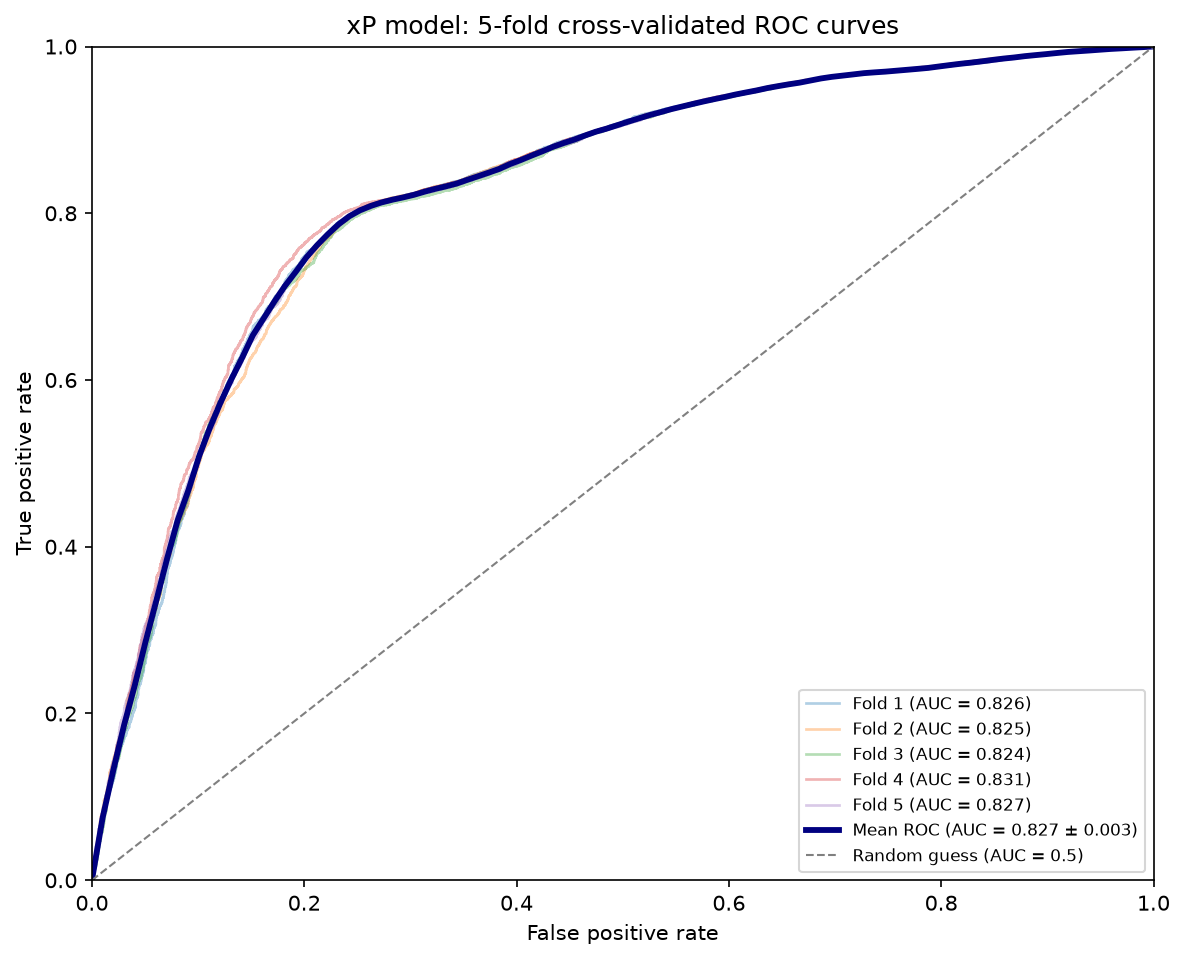

In [17]:
from sklearn.metrics import roc_curve
from sklearn.model_selection import StratifiedKFold

fig, ax = plt.subplots(figsize=(8, 6.5), dpi=150)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
mean_fpr = np.linspace(0, 1, 100)
tprs = []

for fold_i, (train_idx, test_idx) in enumerate(skf.split(X_xp_all, y_xp_all)):
    X_train_fold, X_test_fold = X_xp_all.iloc[train_idx], X_xp_all.iloc[test_idx]
    y_train_fold, y_test_fold = y_xp_all.iloc[train_idx], y_xp_all.iloc[test_idx]

    fold_model = LogisticRegression()
    fold_model.fit(X_train_fold, y_train_fold)
    probs = fold_model.predict_proba(X_test_fold)[:, 1]

    fpr, tpr, _ = roc_curve(y_test_fold, probs)
    fold_auc = roc_auc_score(y_test_fold, probs)
    ax.plot(fpr, tpr, alpha=0.35, linewidth=1.3, label=f"Fold {fold_i+1} (AUC = {fold_auc:.3f})")

    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = roc_auc_score(y_xp_all, xp_model_full.predict_proba(X_xp_all)[:, 1])  # full-model reference

ax.plot(mean_fpr, mean_tpr, color='navy', linewidth=2.8,
        label=f"Mean ROC (AUC = {cv_aucs.mean():.3f} $\\pm$ {cv_aucs.std():.3f})")

ax.plot([0, 1], [0, 1], linestyle='--', color='grey', linewidth=1, label="Random guess (AUC = 0.5)")

ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("xP model: 5-fold cross-validated ROC curves")
ax.legend(loc="lower right", fontsize=8)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
fig.tight_layout()

fig.savefig('../data/results/xp_model_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

All 5 fold curves sit almost on top of each other, visually matching the low std above, and the curve stays well clear of the random-guess diagonal across the full range. The flattening around FPR 0.2 to 0.25 marks where the easy cases run out and the harder, more ambiguous passes start, expected behaviour for a 3-feature model rather than a sign of a problem.

Load the per-candidate breakdown from notebook 1

candidates_all3 has one row per teammate who was a candidate receiver for each pass, with their location, VAEP value, and vision-cone visibility already computed. Merge in the real pass value from cf_valid_all3 since the candidate rows do not carry it themselves.

In [18]:
candidate_files = glob.glob('../data/candidates_all3/candidates_match_*.pkl')
candidates_all3 = pd.concat([pd.read_pickle(f) for f in candidate_files], ignore_index=True)
print(f"{len(candidates_all3)} candidate rows across {len(candidate_files)} matches")

candidates_all3 = candidates_all3.merge(
    cf_valid_all3[['match_id', 'original_event_id', 'real_value']],
    on=['match_id', 'original_event_id'],
    how='left'
)
print(f"{candidates_all3['real_value'].isna().sum()} rows missing a real_value after merge (expect a small number, these are passes cf_valid_all3 dropped for having no visible alternative at all)")

664510 candidate rows across 166 matches
101193 rows missing a real_value after merge (expect a small number, these are passes cf_valid_all3 dropped for having no visible alternative at all)


101193 missing is not a bug, it lines up with what RQ1 already found. cf_valid_all3 only keeps passes with at least one visible candidate, so any pass here where every candidate was outside the vision cone has nothing to merge real_value from. RQ1's all-3-competitions summary showed about 16.9% of passes had zero visible candidates (82 045 of 98 652), and 101 193 of 664 510 rows (15.2%) is the same story at the row level, a "no visible candidate" pass can contribute several invisible-candidate rows, not just one, so the percentages do not need to match exactly to be consistent.

No fix needed downstream either. These rows carry NaN for real_value, and candidate_value > real_value evaluates to False against NaN rather than erroring, so they will never qualify as forward-progressive later. That is correct: a pass with no visible alternative cannot have a visible forward-progressive option that was bypassed.

Classify each candidate as offside, and compute xP, in one pass over the frames

candidates_all3 only has the candidate and passer locations, not the defender positions needed for offside or xP, those live in the 360 frame. This re-fetches frames per match, once each, using the cache from earlier so this only hits the network for matches not already cached. For every pass event, it computes the offside line once and the xP features for every candidate of that pass, reusing the same frame fetch for both rather than fetching twice.

In [22]:
from collections import defaultdict

unique_match_ids = candidates_all3['match_id'].unique()
combined_rows = []
skipped_events = 0

# group once per match, and once per event within each match, instead of
# filtering the full 664k-row table from scratch for every single event
candidates_by_match = {mid: df for mid, df in candidates_all3.groupby('match_id')}

for i, mid in enumerate(unique_match_ids):
    m_frames = cached_frames(str(mid))
    m_events = cached_events(str(mid))
    m_events_indexed = m_events.set_index('id')

    match_candidates = candidates_by_match[mid]
    candidates_by_event = {eid: df for eid, df in match_candidates.groupby('original_event_id')}
    match_event_ids = match_candidates['original_event_id'].unique()

    # first pass: collect the opponent keeper's x-position wherever it happens to be
    # visible, grouped by team and period, so a missing keeper in one frame can fall
    # back to a robust estimate from other passes by the same team in the same half
    keeper_positions = defaultdict(list)
    event_frames = {}
    event_team_period = {}

    for event_id in match_event_ids:
        frame_at_event = m_frames[m_frames['id'] == event_id]
        event_frames[event_id] = frame_at_event
        if frame_at_event.empty:
            continue
        if event_id not in m_events_indexed.index:
            continue
        ev = m_events_indexed.loc[event_id]
        team = ev['team']
        period = ev['period']
        event_team_period[event_id] = (team, period)

        opponent_keeper = frame_at_event[(frame_at_event['teammate'] == False) & (frame_at_event['keeper'] == True)]
        if not opponent_keeper.empty:
            keeper_positions[(team, period)].append(opponent_keeper.iloc[0]['location'][0])

    attacking_direction = {key: np.median(vals) for key, vals in keeper_positions.items()}

    # second pass: classify every event, preferring its own keeper position when
    # visible, falling back to the team and period estimate otherwise. xp_value
    # is not computed here anymore, just the features, so the model only runs once
    # at the very end on the full batch
    for event_id in match_event_ids:
        frame_at_event = event_frames[event_id]
        if frame_at_event.empty:
            skipped_events += 1
            continue

        team_period = event_team_period.get(event_id)
        opponent_keeper = frame_at_event[(frame_at_event['teammate'] == False) & (frame_at_event['keeper'] == True)]
        if not opponent_keeper.empty:
            attacking_toward_x = opponent_keeper.iloc[0]['location'][0]
        elif team_period in attacking_direction:
            attacking_toward_x = attacking_direction[team_period]
        else:
            skipped_events += 1
            continue

        offside_line_x = compute_offside_line(frame_at_event, attacking_toward_x)

        event_candidates = candidates_by_event.get(event_id)
        if event_candidates is None or event_candidates.empty:
            continue
        passer_loc = event_candidates.iloc[0]['passer_location']

        for _, row in event_candidates.iterrows():
            cand_loc = row['candidate_location']
            offside = is_offside(cand_loc[0], passer_loc[0], offside_line_x, attacking_toward_x)
            xp_features = compute_xp_features(passer_loc, cand_loc, frame_at_event)

            combined_rows.append({
                'match_id': mid,
                'original_event_id': event_id,
                'cand_x': round(cand_loc[0], 4),
                'cand_y': round(cand_loc[1], 4),
                'offside': offside,
                'xp_features': xp_features,
                'attacking_toward_x': attacking_toward_x,
            })

    if (i + 1) % 20 == 0:
        print(f"[{i+1}/{len(unique_match_ids)}] matches processed, {skipped_events} events skipped so far")

print(f"Done classifying offside and features. {len(combined_rows)} candidate rows. {skipped_events} events skipped entirely (no frame data and no team/period fallback available).")

# batch the xP prediction in a single call instead of one row at a time
filters_df = pd.DataFrame(combined_rows)
xp_feature_df = pd.DataFrame(list(filters_df['xp_features']))
filters_df['xp_value'] = xp_model_full.predict_proba(xp_feature_df)[:, 1]
filters_df = filters_df.drop(columns=['xp_features'])

candidates_all3['cand_x'] = candidates_all3['candidate_location'].apply(lambda loc: round(loc[0], 4))
candidates_all3['cand_y'] = candidates_all3['candidate_location'].apply(lambda loc: round(loc[1], 4))

candidates_full = candidates_all3.merge(
    filters_df,
    on=['match_id', 'original_event_id', 'cand_x', 'cand_y'],
    how='left'
)
print(f"{len(candidates_full)} rows after merge, {candidates_full['offside'].isna().sum()} unmatched")
print(candidates_full['offside'].value_counts())

[20/166] matches processed, 206 events skipped so far
[40/166] matches processed, 291 events skipped so far
[60/166] matches processed, 369 events skipped so far
[80/166] matches processed, 446 events skipped so far
[100/166] matches processed, 524 events skipped so far
[120/166] matches processed, 530 events skipped so far
[140/166] matches processed, 530 events skipped so far
[160/166] matches processed, 582 events skipped so far
Done classifying offside and features. 660784 candidate rows. 582 events skipped entirely (no frame data and no team/period fallback available).
664518 rows after merge, 3726 unmatched
offside
False    587078
True      73714
Name: count, dtype: int64


Offside and xP classification, corrected

The keeper fallback resolved the coverage gap from the first version. Of 664518 candidate rows, 660792 were successfully classified for offside status and expected pass completion probability, leaving only 3726 unmatched (0.56 percent), down from 577074 unmatched in the naive version. The remaining gaps come from 582 events where neither the individual frame nor any frame from the same team and period in that match showed the opposing keeper, meaning no attacking direction could be estimated at all.

Of the classified candidates, 73714 (11.1 percent) are offside, leaving the large majority as legitimate passing options once perception, offside status, and completion probability are all accounted for.

Sanity check for xT

In [24]:
import numpy as np
from scipy.interpolate import RegularGridInterpolator
from socceraction.spadl import config as spadlconfig

# socceraction's own interpolator() method calls scipy's interp2d, which was
# removed in scipy 1.14+. this rebuilds the same interpolation using
# RegularGridInterpolator instead, working directly off the loaded xT grid

_xt_grid = xT_model.xT  # shape (n_y_bins, n_x_bins)
_n_y_bins, _n_x_bins = _xt_grid.shape
_cell_length = spadlconfig.field_length / _n_x_bins
_cell_width = spadlconfig.field_width / _n_y_bins
_x_centers = np.arange(0.0, spadlconfig.field_length, _cell_length) + 0.5 * _cell_length
_y_centers = np.arange(0.0, spadlconfig.field_width, _cell_width) + 0.5 * _cell_width

_xt_interpolator = RegularGridInterpolator(
    (_x_centers, _y_centers),
    _xt_grid.T,
    bounds_error=False,
    fill_value=None,
)

def get_xt_value(x, y):
    x_clipped = np.clip(x, 0, spadlconfig.field_length)
    y_clipped = np.clip(y, 0, spadlconfig.field_width)
    return float(_xt_interpolator([[x_clipped, y_clipped]])[0])

# same sanity check as before, now using get_xt_value instead of xT_model.interpolator()
test_points = [
    (60, 40, "halfway line, center"),
    (100, 40, "edge of box, center"),
    (114, 40, "six-yard box, center"),
    (20, 40, "own defensive third, center"),
    (100, 5, "edge of box, wide touchline"),
]

for x, y, label in test_points:
    val = get_xt_value(x, y)
    print(f"{label}: ({x}, {y}) -> xT = {val:.4f}")

halfway line, center: (60, 40) -> xT = 0.0179
edge of box, center: (100, 40) -> xT = 0.2091
six-yard box, center: (114, 40) -> xT = 0.2780
own defensive third, center: (20, 40) -> xT = 0.0102
edge of box, wide touchline: (100, 5) -> xT = 0.0384


In [25]:
# wraps the working interpolator from the sanity check above with attacking-direction
# mirroring, so "forward" always means toward the opponent's goal regardless of which
# side of the pitch a team is defending
def get_xt_value(x, y, attacking_toward_x):
    if attacking_toward_x < 60:
        x = 120 - x
    x_clipped = np.clip(x, 0, spadlconfig.field_length)
    y_clipped = np.clip(y, 0, spadlconfig.field_width)
    return float(_xt_interpolator([[x_clipped, y_clipped]])[0])

Forward-progressive classification and the legitimate candidate pool

A candidate is forward-progressive if the target zone's xT exceeds the origin zone's xT, and its VAEP value exceeds the value of the pass actually made. A candidate is a legitimate alternative if it is visible, not offside, and has at least a minimal completion probability.

In [26]:
candidates_full['xt_origin'] = candidates_full.apply(
    lambda row: get_xt_value(row['passer_location'][0], row['passer_location'][1], row['attacking_toward_x']),
    axis=1
)
candidates_full['xt_target'] = candidates_full.apply(
    lambda row: get_xt_value(row['candidate_location'][0], row['candidate_location'][1], row['attacking_toward_x']),
    axis=1
)

candidates_full['forward_progressive'] = (
    (candidates_full['xt_target'] > candidates_full['xt_origin']) &
    (candidates_full['candidate_value'] > candidates_full['real_value'])
)

XP_THRESHOLD = 0.05  # unrealistically difficult passes excluded below this, tune if needed

candidates_full['legitimate_forward_progressive'] = (
    candidates_full['visible']
    & (~candidates_full['offside'].fillna(True))
    & (candidates_full['xp_value'] >= XP_THRESHOLD)
    & candidates_full['forward_progressive']
)

print(candidates_full['forward_progressive'].value_counts())
print(candidates_full['legitimate_forward_progressive'].value_counts())

forward_progressive
False    411738
True     252780
Name: count, dtype: int64
legitimate_forward_progressive
False    577733
True      86785
Name: count, dtype: int64


C:\Users\raees\AppData\Local\Temp\ipykernel_14876\835163793.py:19: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & (~candidates_full['offside'].fillna(True))


Forward-progressive candidates and the legitimate pool

Of 664518 candidate rows, 252780 (38.0 percent) qualify as forward-progressive, meaning the target zone has higher expected threat than the origin zone and the candidate's VAEP value exceeds the value of the pass actually made. Narrowing this to candidates that were also visible within the 120 degree vision cone, not offside, and above the 0.05 completion probability threshold leaves 86785 legitimate forward-progressive alternatives, 13.1 percent of all candidates and about a third of the forward-progressive ones. This gap between forward-progressive and legitimate is expected, since most forward-progressive candidates will fail on visibility or offside status alone, confirming the perception and legality filters are doing meaningful work rather than passing nearly everything through.

The RQ2 forward-bias rate

Per proposal Section 4.5.2, for every pass with at least one legitimate forward-progressive alternative available, was that alternative bypassed. Since a candidate only counts as forward-progressive when its value exceeds the real pass's value, any pass where the player actually took the best option by construction has no qualifying candidate, so this does not need to separately exclude the chosen teammate from the candidate pool.

In [27]:
from scipy.stats import binomtest

pass_level = candidates_full.groupby(['match_id', 'original_event_id']).agg(
    had_legit_forward_option=('legitimate_forward_progressive', 'any')
).reset_index()

n_total = len(pass_level)
n_bypassed = pass_level['had_legit_forward_option'].sum()
forward_bias_rate = n_bypassed / n_total

print(f"Total passes: {n_total}")
print(f"Passes with a legitimate forward-progressive option that was bypassed: {n_bypassed}")
print(f"Forward-bias rate: {forward_bias_rate:.1%}")

result = binomtest(n_bypassed, n_total, p=0.5)
print(f"Binomial test vs random selection: p={result.pvalue:.4f}")

pass_level.to_pickle('../data/results/rq2_forward_bias_rate.pkl')

Total passes: 98652
Passes with a legitimate forward-progressive option that was bypassed: 42193
Forward-bias rate: 42.8%
Binomial test vs random selection: p=0.0000


The RQ2 forward-bias rate

Across 98652 qualifying passes, 42193 (42.8 percent) had at least one legitimate forward-progressive alternative available, visible, onside, and completable, that the player did not take. A binomial test against a 50 percent null shows this is statistically significant (p < 0.0001), though with a sample this large even a modest deviation from 50 percent will register as significant, so the effect size itself, not just the p-value, is what carries the argument here. Just under half of all qualifying passes bypassed a forward-progressive option that perception, offside status, and pass difficulty all suggest was available and reasonable.

In [28]:
import numpy as np
from scipy.stats import norm

def wilson_ci(n_success, n_total, alpha=0.05):
    z = norm.ppf(1 - alpha / 2)
    phat = n_success / n_total
    denom = 1 + z**2 / n_total
    centre = phat + z**2 / (2 * n_total)
    adj = z * np.sqrt(phat * (1 - phat) / n_total + z**2 / (4 * n_total**2))
    return (centre - adj) / denom, (centre + adj) / denom

ci_low, ci_high = wilson_ci(n_bypassed, n_total)
print(f"Forward-bias rate: {forward_bias_rate:.1%} (95% CI: {ci_low:.1%} to {ci_high:.1%})")

Forward-bias rate: 42.8% (95% CI: 42.5% to 43.1%)


Interpreting the forward-bias rate

RQ2 asks whether players systematically pass backward or sideways even when a forward-progressive option is genuinely available to them, not just theoretically open somewhere on the pitch, but visible within their own field of view, not offside, and realistically completable. The 42.8 percent forward-bias rate means that in just under half of the 98652 qualifying passes, a player had exactly this kind of option in front of them and chose not to take it.

This is the central evidence for H2, that decision-making bias exists independently of perceptual constraint. Layer 1 already showed that a large share of counterfactual passing options are invisible to the passer in the first place. This result goes further: even restricting entirely to options the player could plausibly see and legally execute, bypassing still happens close to half the time. That gap is not explained by what the player could perceive, since visibility has already been filtered for, which points toward a genuine decision-making tendency toward caution or retention over forward progression, consistent with the directional bias literature this thesis builds on.

The finding is not that players are making mistakes. A bypassed forward option can still be the sensible choice for reasons the value model does not capture, game state, risk tolerance, a better second option nearby. The claim is narrower and better supported: forward progression is being left on the table at a rate too high to attribute to perception or legality alone.

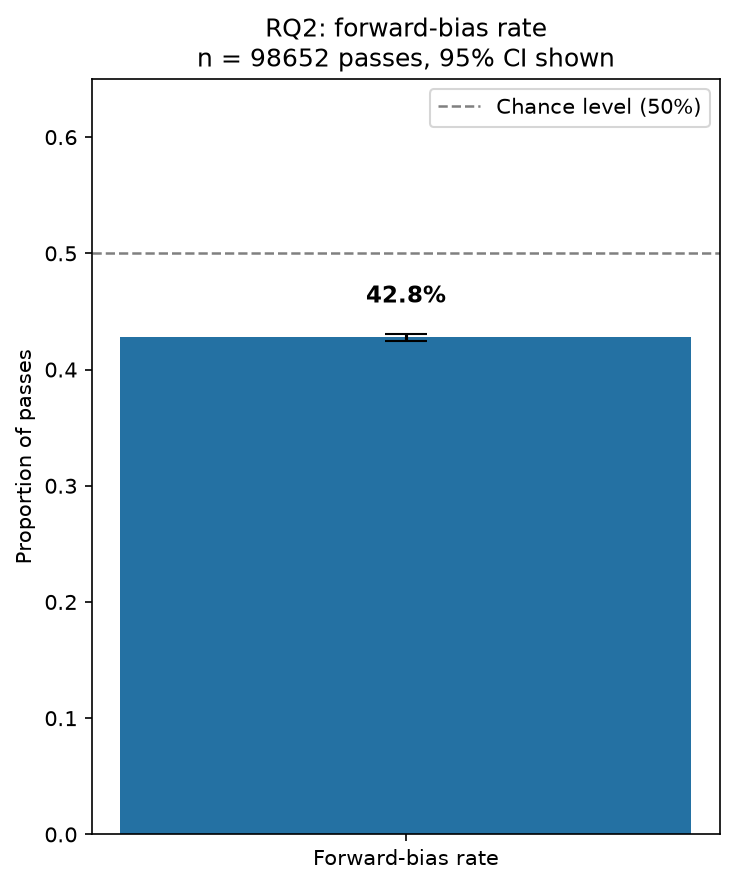

In [29]:
fig, ax = plt.subplots(figsize=(5, 6), dpi=150)

ax.bar(['Forward-bias rate'], [forward_bias_rate], color='#2471a3', width=0.45,
       yerr=[[forward_bias_rate - ci_low], [ci_high - forward_bias_rate]],
       capsize=10, ecolor='black', error_kw={'elinewidth': 1.5})
ax.axhline(0.5, linestyle='--', color='grey', linewidth=1.2, label='Chance level (50%)')

ax.set_ylim(0, 0.65)
ax.set_ylabel('Proportion of passes')
ax.set_title(f'RQ2: forward-bias rate\nn = {n_total} passes, 95% CI shown')
ax.legend(loc='upper right')
for i, v in enumerate([forward_bias_rate]):
    ax.text(i, v + 0.03, f"{v:.1%}", ha='center', fontsize=11, fontweight='bold')

fig.tight_layout()
fig.savefig('../data/results/rq2_forward_bias_rate.png', dpi=300, bbox_inches='tight')
plt.show()

The forward-bias rate sits comfortably below the 50 percent chance line, at 42.8 percent with a tight 95 percent confidence interval of 42.5 to 43.1 percent. The narrowness of that interval comes from the large sample size, 98652 passes, rather than suggesting the effect itself is small. Just under half of all passes with a legitimate forward-progressive alternative saw that alternative bypassed.

In [32]:
from scipy.stats import chi2_contingency

match_competition = {}
for mid in matches_euro2024['match_id']:
    match_competition[str(mid)] = 'Euro 2024'
for mid in matches_euro2020['match_id']:
    match_competition[str(mid)] = 'Euro 2020'
for mid in matches_wc2022['match_id']:
    match_competition[str(mid)] = 'World Cup 2022'

pass_level['competition'] = pass_level['match_id'].astype(str).map(match_competition)
print(pass_level['competition'].value_counts(dropna=False))

comp_summary = pass_level.groupby('competition')['had_legit_forward_option'].agg(
    n_bypassed='sum', n_total='count'
)
comp_summary['rate'] = comp_summary['n_bypassed'] / comp_summary['n_total']

ci_low_arr, ci_high_arr = wilson_ci(comp_summary['n_bypassed'].values, comp_summary['n_total'].values)
comp_summary['ci_low'] = ci_low_arr
comp_summary['ci_high'] = ci_high_arr

print(comp_summary)

contingency = pd.crosstab(pass_level['competition'], pass_level['had_legit_forward_option'])
chi2, p_chi2, dof, expected = chi2_contingency(contingency)
print(f"\nChi-square test for homogeneity across competitions: chi2={chi2:.3f}, p={p_chi2:.4f}")

competition
World Cup 2022    36753
Euro 2024         31537
Euro 2020         30362
Name: count, dtype: int64
                n_bypassed  n_total      rate    ci_low   ci_high
competition                                                      
Euro 2020            12956    30362  0.426718  0.421164  0.432290
Euro 2024            14413    31537  0.457019  0.451526  0.462522
World Cup 2022       14824    36753  0.403341  0.398336  0.408366

Chi-square test for homogeneity across competitions: chi2=199.964, p=0.0000


Forward-bias rate by competition

The bias rate holds in the same direction across all three tournaments, all sit clearly below the 50 percent chance level, ranging from 40.3 percent in World Cup 2022 to 45.7 percent in Euro 2024, with Euro 2020 in between at 42.7 percent. The chi-square test shows this difference between competitions is statistically significant (p < 0.0001), but with a sample this large, as with the earlier binomial test, statistical significance does not by itself imply a practically large difference. A 5.4 percentage point spread across three tournaments played years apart, under different competition formats and squads, is a modest range for what is fundamentally the same underlying pattern: none of the three competitions comes close to the 50 percent chance level, and all three show players bypassing a legitimate forward-progressive option roughly two out of every five passes. The core finding is not an artifact of any single tournament.

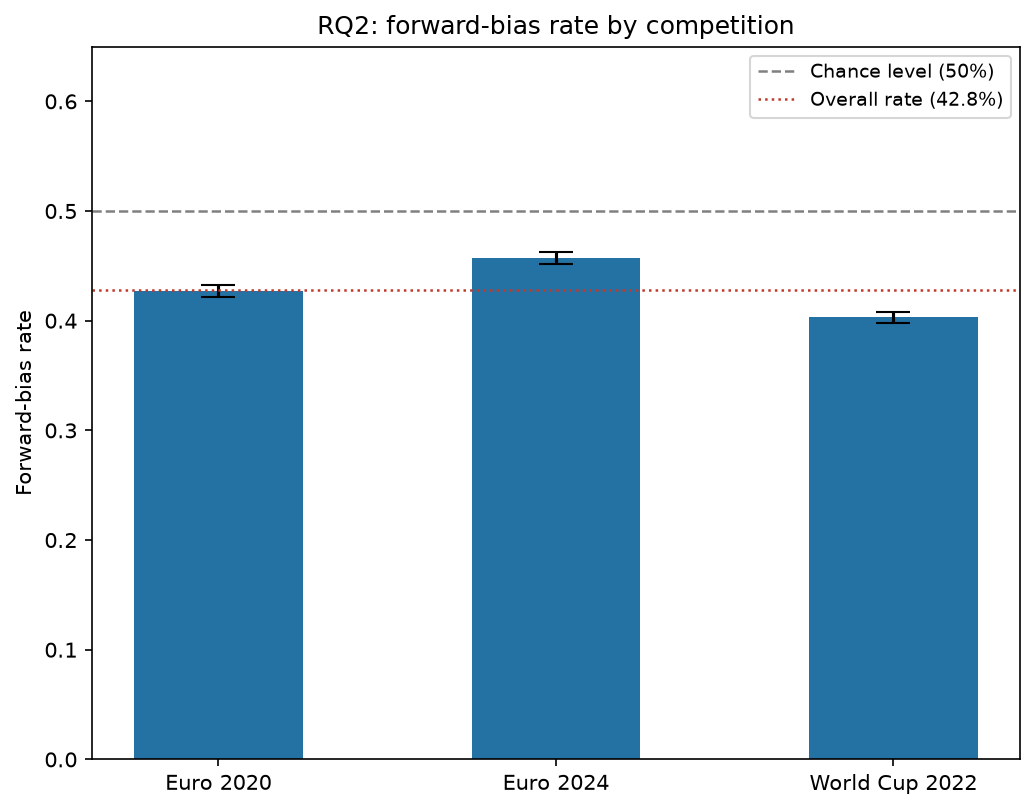

In [33]:
fig, ax = plt.subplots(figsize=(7, 5.5), dpi=150)

comps = comp_summary.index.tolist()
rates = comp_summary['rate'].values
err_low = rates - comp_summary['ci_low'].values
err_high = comp_summary['ci_high'].values - rates

ax.bar(comps, rates, color='#2471a3', width=0.5,
       yerr=[err_low, err_high], capsize=8, ecolor='black')
ax.axhline(0.5, linestyle='--', color='grey', linewidth=1.2, label='Chance level (50%)')
ax.axhline(forward_bias_rate, linestyle=':', color='#c0392b', linewidth=1.2, label=f'Overall rate ({forward_bias_rate:.1%})')

ax.set_ylim(0, 0.65)
ax.set_ylabel('Forward-bias rate')
ax.set_title('RQ2: forward-bias rate by competition')
ax.legend(loc='upper right', fontsize=9)

fig.tight_layout()
fig.savefig('../data/results/rq2_bias_rate_by_competition.png', dpi=300, bbox_inches='tight')
plt.show()